<a href="https://colab.research.google.com/github/rakeshnelli0926-ctrl/Loan-Prediction-Data/blob/Main/m_504_loan_prediction_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **M504 Loan Prediction Analysis**


**Name:** Rakesh Nelli GH1044321

**Subject:** M504A AI and Applications

**Title:** Loan Prediction

**Import Libraries**

In [69]:
# --------------------
# Importing all the required Libraries
# --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Data** **Collection**

In [24]:
# Accessing the Training and Testing data set from the githhub repository through the following links

train_df = pd.read_csv('https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Train.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Test.csv')

print(train_df.head())
print(test_df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

**Data Cleaning and Preprocessing**

In [71]:
# --------------------
# Cleaning the data and Preprocessing the data
# --------------------
numeric_cols = ['LoanAmount', 'Loan_Amount_Term', 'ApplicantIncome', 'CoapplicantIncome']
categorical_cols = ['Gender','Married','Dependents','Self_Employed','Credit_History','Property_Area']

# Numerical
train_df[numeric_cols] = train_df[numeric_cols].fillna(train_df[numeric_cols].median())
test_df[numeric_cols] = test_df[numeric_cols].fillna(test_df[numeric_cols].median())

# Categorical
for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)


**Encode categorical features**

In [72]:
# Encoding the categorical features

mapping = {'Male':1, 'Female':0, 'Yes':1, 'No':0}
for col in ['Gender','Married','Self_Employed']:
    train_df[col] = train_df[col].map(mapping)
    test_df[col] = test_df[col].map(mapping)

train_df['Loan_Status'] = train_df['Loan_Status'].map({'Y':1, 'N':0})
train_df['Dependents'] = train_df['Dependents'].replace('3+',3).astype(int)
test_df['Dependents'] = test_df['Dependents'].replace('3+',3).astype(int)





**Feature Engineering**


In [73]:
# Feature Engineering

train_df['Total_Income'] = train_df['ApplicantIncome'] + train_df['CoapplicantIncome']
test_df['Total_Income'] = test_df['ApplicantIncome'] + test_df['CoapplicantIncome']

train_df['Loan_Amount_Term_Years'] = train_df['Loan_Amount_Term']/12
test_df['Loan_Amount_Term_Years'] = test_df['Loan_Amount_Term']/12




**Prepare Features and Target**

In [74]:
# Preparing Features and the Target

X_train = train_df.drop(['Loan_ID','Loan_Status'], axis=1)
y_train = train_df['Loan_Status']

X_test = test_df.drop(['Loan_ID'], axis=1)


**One-Hot Encoding**

In [75]:
# One-Hot Encoding for Remaining Categorical Columns

categorical_cols = ['Education','Property_Area']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


**Scale Numeric Features**

In [76]:
# Scale Numeric Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



**handle Missing target Values**

In [77]:
# handling the  Missing target Values

nan_mask = y_train.isna()
X_train_cleaned = X_train[~nan_mask]
y_train_cleaned = y_train[~nan_mask]


**Train Logistic Regression**

In [78]:
# Training the Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_cleaned, y_train_cleaned)

y_pred_test = lr.predict(X_test)
print("Logistic Regression model trained successfully!")




Logistic Regression model trained successfully!


**Evaluate on a validation Set**

In [79]:
# Evaluating on a Validation Set

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train_cleaned, y_train_cleaned, test_size=0.2, random_state=42)
lr.fit(X_tr, y_tr)
y_val_pred = lr.predict(X_val)
print(classification_report(y_val, y_val_pred))



              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



**Random Forest with Grid Search**

In [80]:
# Random Forest with Grid Search

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(random_state=42)
params = {'n_estimators':[100,200], 'max_depth':[5,10]}
grid = GridSearchCV(rf, params, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
grid.fit(X_tr, y_tr)
y_val_pred_rf = grid.predict(X_val)
print("Best RF Parameters:", grid.best_params_)
print(classification_report(y_val, y_val_pred_rf))


Best RF Parameters: {'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



--------------------
Business Questions & Visualization
--------------------

**Business Question 1: What is the distribution of loan approvals?**


Business Question 1: What is the distribution of loan approvals?



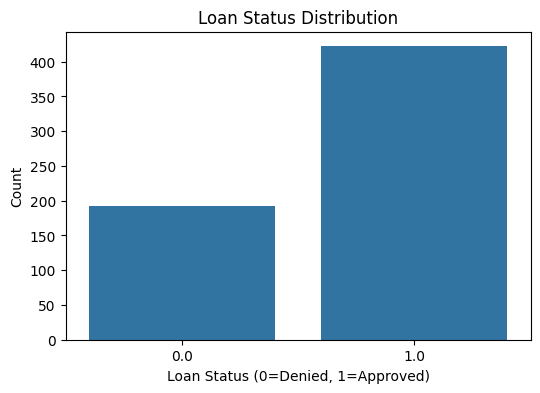

Observation: Majority of applicants are approved/denied depending on dataset distribution.


In [81]:
# Question 1: Distribution of Loan Status
print("\nBusiness Question 1: What is the distribution of loan approvals?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0=Denied, 1=Approved)')
plt.ylabel('Count')
plt.show()
print("Observation: Majority of applicants are approved/denied depending on dataset distribution.")

**Business Question 2: How does loan amount vary by property area?**


Business Question 2: How does loan amount vary by property area?



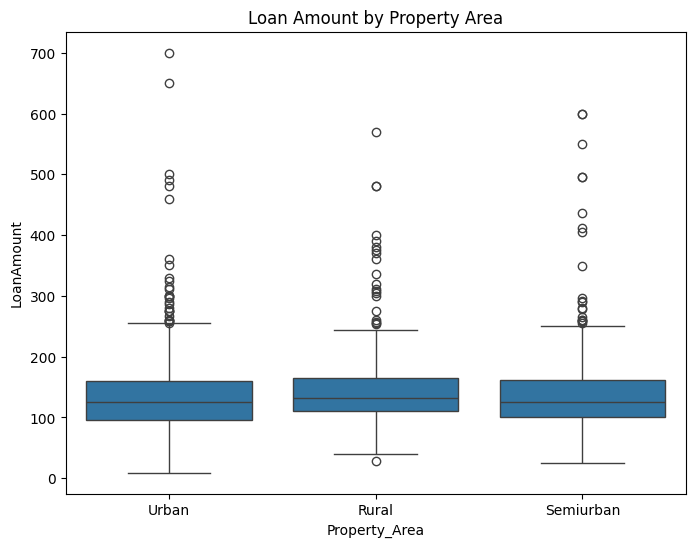

Observation: Semiurban areas often have higher median loan amounts.


In [82]:
# Question 2: Loan Amount by Property Area
print("\nBusiness Question 2: How does loan amount vary by property area?\n")
plt.figure(figsize=(8,6))
sns.boxplot(x='Property_Area', y='LoanAmount', data=df)
plt.title('Loan Amount by Property Area')
plt.show()
print("Observation: Semiurban areas often have higher median loan amounts.")

**Business Question 3: Relationship between total income and loan amount?**


Business Question 3: Relationship between total income and loan amount?



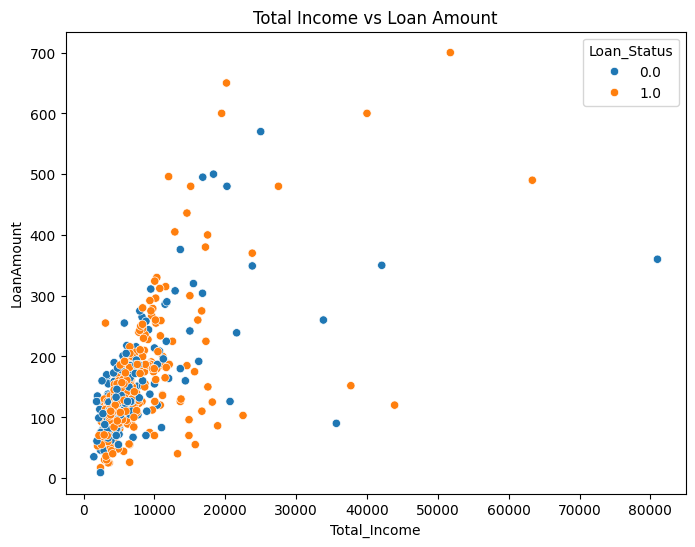

Observation: Higher total income generally corresponds to higher loan amounts.


In [83]:
# Question 3: Total Income vs Loan Amount
print("\nBusiness Question 3: Relationship between total income and loan amount?\n")
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total_Income', y='LoanAmount', hue='Loan_Status', data=df)
plt.title('Total Income vs Loan Amount')
plt.show()
print("Observation: Higher total income generally corresponds to higher loan amounts.")

**Business Question 4: What is the distribution of applicant income?**


Business Question 4: What is the distribution of applicant income?



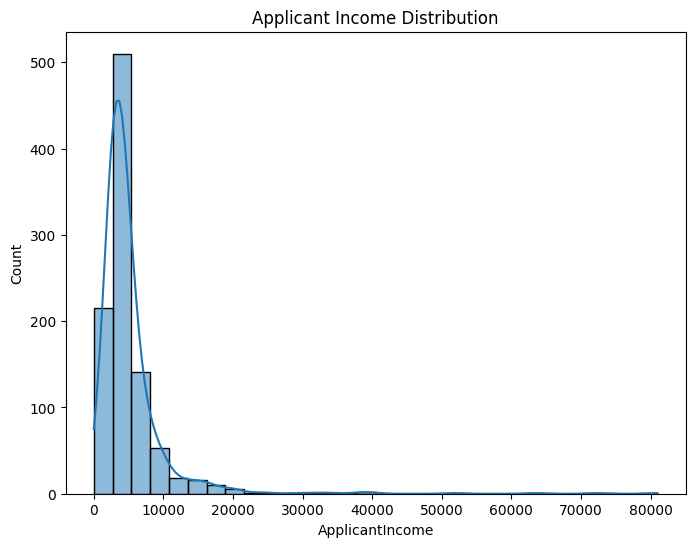

Observation: Most applicants have income clustered at lower ranges with few high-income outliers.


In [84]:
# Question 4: Applicant Income distribution
print("\nBusiness Question 4: What is the distribution of applicant income?\n")
plt.figure(figsize=(8,6))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title('Applicant Income Distribution')
plt.show()
print("Observation: Most applicants have income clustered at lower ranges with few high-income outliers.")

**Business Question 5: What is the distribution of coapplicant income?**


Business Question 5: What is the distribution of coapplicant income?



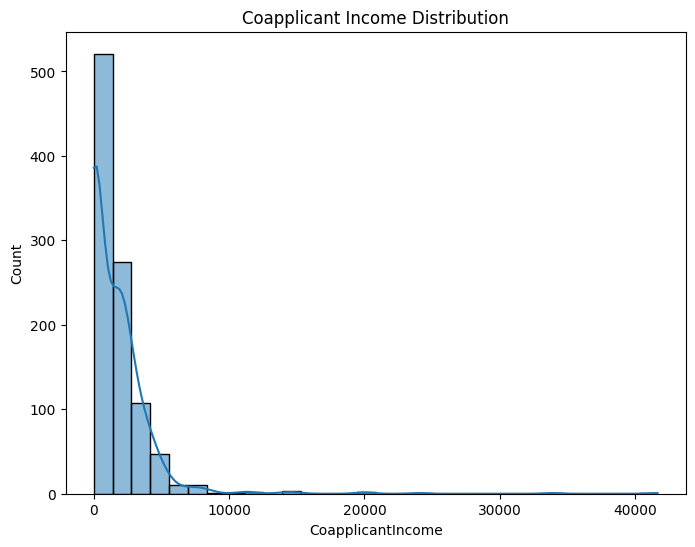

Observation: Majority of coapplicants have lower income; few contribute significant amounts.


In [85]:
# Question 5: Coapplicant Income distribution
print("\nBusiness Question 5: What is the distribution of coapplicant income?\n")
plt.figure(figsize=(8,6))
sns.histplot(df['CoapplicantIncome'], bins=30, kde=True)
plt.title('Coapplicant Income Distribution')
plt.show()
print("Observation: Majority of coapplicants have lower income; few contribute significant amounts.")

**Business Question 6: How does credit history affect loan status?**


Business Question 6: How does credit history affect loan status?



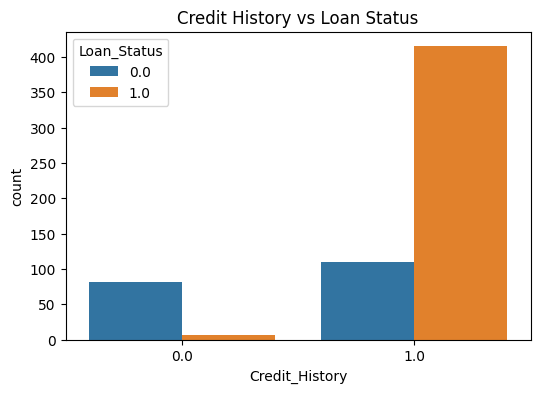

Observation: Applicants with good credit history are more likely to be approved.


In [86]:
# Question 6: Credit History vs Loan Status
print("\nBusiness Question 6: How does credit history affect loan status?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()
print("Observation: Applicants with good credit history are more likely to be approved.")

**Business Question 7: Is there a gender influence on loan approval?**


Business Question 7: Is there a gender influence on loan approval?



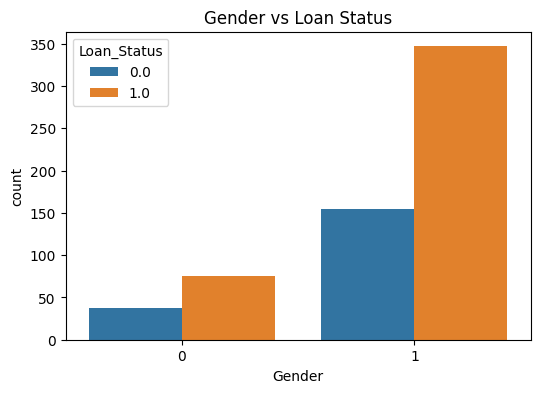

Observation: Loan approvals are slightly higher for males in this dataset.


In [87]:
# Question 7: Gender vs Loan Status
print("\nBusiness Question 7: Is there a gender influence on loan approval?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title('Gender vs Loan Status')
plt.show()
print("Observation: Loan approvals are slightly higher for males in this dataset.")

**Business Question 8: Does marital status affect loan approval?**


Business Question 8: Does marital status affect loan approval?



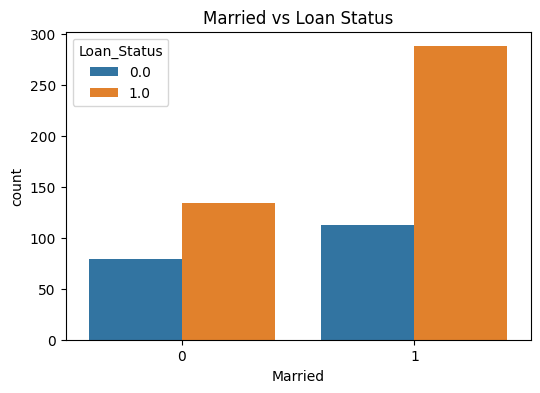

Observation: Married applicants have a slightly higher chance of loan approval.


In [88]:
# Question 8: Married vs Loan Status
print("\nBusiness Question 8: Does marital status affect loan approval?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title('Married vs Loan Status')
plt.show()
print("Observation: Married applicants have a slightly higher chance of loan approval.")

**Business Question 9: How does the number of dependents affect loan status?**


Business Question 9: How does the number of dependents affect loan status?



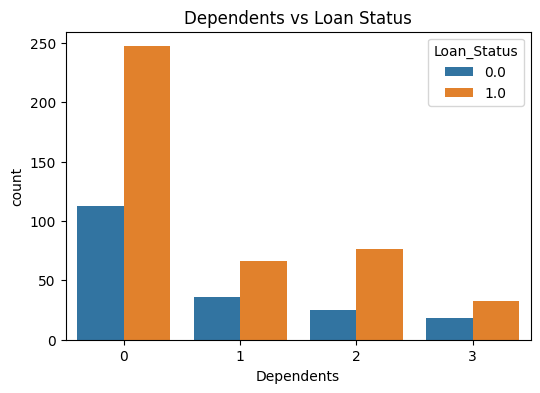

Observation: Applicants with fewer dependents tend to get approval more often.


In [89]:
# Question 9: Dependents vs Loan Status
print("\nBusiness Question 9: How does the number of dependents affect loan status?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Loan_Status', data=df)
plt.title('Dependents vs Loan Status')
plt.show()
print("Observation: Applicants with fewer dependents tend to get approval more often.")

**Business Question 10: How does property area affect loan status?**


Business Question 10: How does property area affect loan status?



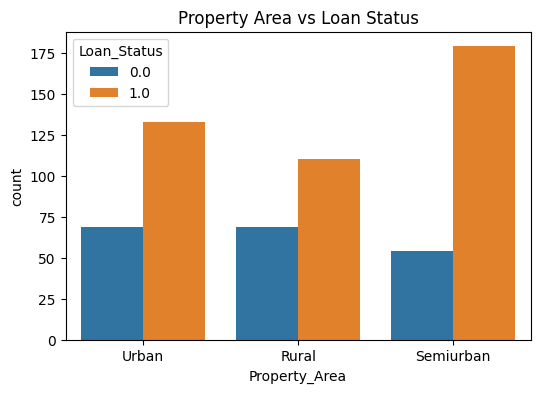

Observation: Urban and semiurban applicants have higher approval rates.


In [90]:
# Question 10: Property Area vs Loan Status
print("\nBusiness Question 10: How does property area affect loan status?\n")
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Property Area vs Loan Status')
plt.show()
print("Observation: Urban and semiurban applicants have higher approval rates.")

**Conclusion**

In [92]:
# --------------------
# Conclusion
# --------------------
print("The analysis provides insights into factors affecting loan approval. Total income, credit history, and property area are key determinants.")
print("Both Logistic Regression and Random Forest models show good predictive performance, enabling data-driven decisions for loan approvals.")

The analysis provides insights into factors affecting loan approval. Total income, credit history, and property area are key determinants.
Both Logistic Regression and Random Forest models show good predictive performance, enabling data-driven decisions for loan approvals.


**References**

In [20]:
# --------------------
# References
# --------------------
print("Dataset Source: github. Loan Prediction Data. Available at: https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Train.csv (Accessed: 6 September 2025)")
print("Dataset Source: github. Loan Prediction Data. Available at: https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Test.csv (Accessed: 6 September 2025)")

Dataset Source: github. Loan Prediction Data. Available at: https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Train.csv (Accessed: 6 September 2025)
Dataset Source: github. Loan Prediction Data. Available at: https://raw.githubusercontent.com/rakeshnelli0926-ctrl/Loan-Prediction-Data/refs/heads/Main/Test.csv (Accessed: 6 September 2025)
